# 2 — H1: non-uniform degradation

**AHN does not forget uniformly.** Retrieval accuracy declines at different rates for
different information types, with some categories degrading faster than others as
compression accumulates.

Supported if the per-type degradation slopes separate. Refuted if one shared slope fits
every category within its interval.

Categories differ in how guessable they are — a two-way temporal question is right half
the time by chance, a numerical employee ID essentially never. Raw accuracy would credit
temporal facts with robustness they do not have, so every comparison is also reported
chance-corrected.

In [1]:
import sys
from pathlib import Path

here = Path.cwd().resolve()
ROOT = next((p for p in (here, *here.parents) if (p / "config").exists()), here)
sys.path.insert(0, str(ROOT / "src"))

import pandas as pd
from ahnexp import config, h1_degradation, report, schema

MODE = "pilot"
SOURCE = "run"   # "run" | "pilot_csv" | "synthetic"


def load(source, mode):
    if source == "run":
        return pd.read_parquet(config.output_path("raw", mode)), False
    if source == "pilot_csv":
        # The pilot predates the window fix, so the exact/recurrent split here is only
        # as trustworthy as the window we pass in. See open_decisions.md #1.
        return schema.from_pilot_csv(
            ROOT / "data/pilot_raw_results.csv",
            architecture="gated_deltanet",
            sliding_window=256,
        ), False
    from ahnexp._smoke import fake_results
    return fake_results(), True


df, SYNTHETIC = load(SOURCE, MODE)
print(f"{len(df)} trials · {df['architecture'].nunique()} arm(s) · synthetic={SYNTHETIC}")
df.groupby("memory_condition")["correct"].agg(["mean", "size"])

50 trials · 1 arm(s) · synthetic=False


,mean,size
memory_condition,,
exact_memory,1.0,20
recurrent_memory,0.2,30


## Degradation curves per fact type

One curve per category. The x-axis is normalised by the sliding window, so 1.0 is where
the target leaves the lossless KV cache — everything left of that line is the per-type
ceiling, everything right of it is compressed memory.

Bands are 95% percentile intervals from a bootstrap that resamples **seeds**, not
trials. The same items recur across pressure levels, so resampling trials would report
intervals far too tight. With a single seed the bands are empty by design.

fact_type,contradictory,entity-attribute,multi-hop,numerical,temporal
tokens_after_target,,,,,
0,1.0,1.0,1.0,1.0,1.0
132,NaN,NaN,1.0,1.0,NaN
135,NaN,1.0,NaN,NaN,NaN
140,NaN,NaN,NaN,NaN,1.0
144,NaN,NaN,NaN,1.0,NaN
146,1.0,1.0,NaN,NaN,1.0
155,1.0,NaN,1.0,NaN,NaN
259,NaN,NaN,0.0,NaN,1.0
262,0.0,NaN,NaN,NaN,NaN


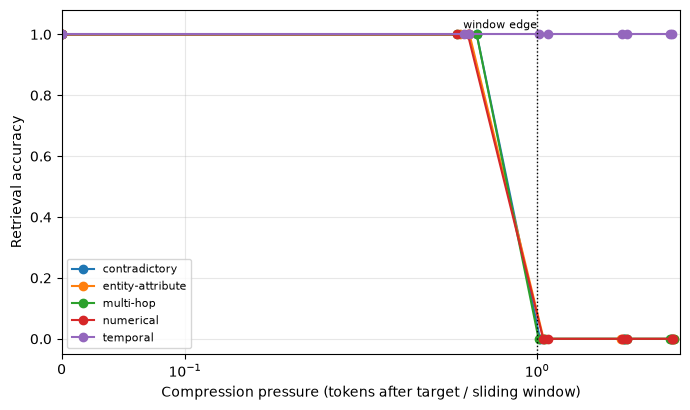

In [2]:
%matplotlib inline
curves = h1_degradation.curves(df, by="fact_type")
report.plot_curves(
    curves,
    group_col="fact_type",
    path=config.figure_path("h1_degradation_by_fact_type", MODE),
    show_threshold=False,
)
curves.pivot(index="tokens_after_target", columns="fact_type", values="accuracy").round(3)

## Degradation slopes — the H1 test

Slope of logit(accuracy) against log2(pressure / window), fitted on the compressed
region only. The logit keeps a drop from 0.9 to 0.8 from looking like a drop from 0.5 to
0.4; normalising by the window makes the rate comparable across checkpoints.

More negative means faster forgetting. `intervals_disjoint` is a coarse screen, not a
test: non-overlapping intervals imply a difference, but overlapping ones do not imply
equality.

In [ ]:
slopes = h1_degradation.slopes(df, by="fact_type")
print(slopes.round(3).to_string(index=False))

separation = h1_degradation.separation(slopes)
disjoint = separation[separation["intervals_disjoint"]]
print(f"\n{len(disjoint)}/{len(separation)} pairs with disjoint intervals")
disjoint.round(3)

       fact_type  slope  ci_low  ci_high  n_levels   n
       multi-hop -1.260  -3.423   -1.089         6 384
       numerical -1.090  -1.504   -0.836         6 384
   contradictory -1.046  -1.334   -0.895         6 384
entity-attribute -0.903  -1.215   -0.737         6 384
        temporal -0.867  -1.149   -0.706         6 384

0/10 pairs with disjoint intervals


,a,b,slope_a,slope_b,intervals_disjoint


## H1 table

`retention` is recurrent accuracy over exact accuracy: what fraction of the in-window
ceiling survives compression. Low retention with a steep slope is H1 support.

The `caveat` column carries the known scoring risks from `config/facts.yaml`. Before
reading a large spread as the H1 effect, check the answer matcher — in the pilot,
`contradictory` scores 0% even in-window where every other type scores 100%, which is a
scoring bug rather than degradation. A broken matcher looks exactly like a strong H1
result. This is blocker #7.

In [4]:
summary = h1_degradation.summary(df).merge(slopes[["fact_type", "slope"]], on="fact_type")

path = report.write_table(
    summary,
    name="h1_degradation",
    title="H1 — Retrieval degradation by information type",
    mode=MODE,
    synthetic=SYNTHETIC,
    notes=[
        f"Bootstrap: cluster on seed, {config.experiment()['statistics']['n_resamples']} resamples.",
        "`retention` = recurrent accuracy / exact accuracy.",
        "Chance floors differ by category; see the chance-corrected column.",
    ],
)
print("wrote", path.relative_to(ROOT))
summary.drop(columns=["caveat"]).round(3)

wrote outputs/tables/h1_degradation_pilot.md


,fact_type,chance,acc_exact,acc_recurrent,retention,chance_corrected_recurrent,retrieval_failure_rate,n,slope
0,multi-hop,0.2,0.734,0.318,0.433,0.147,0.682,576,-1.260
1,numerical,0.0,0.766,0.365,0.476,0.365,0.635,576,-1.090
2,contradictory,0.2,0.797,0.411,0.516,0.264,0.589,576,-1.046
3,entity-attribute,0.2,0.781,0.419,0.537,0.274,0.581,576,-0.903
4,temporal,0.5,0.750,0.490,0.653,-0.021,0.510,576,-0.867
